# 02477 Bayesian Machine Learning 2026: Assignment 1

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as snb
from scipy.stats import beta as beta_dist
from scipy.stats import binom as binom_dist
from scipy.special import beta as beta_fun
from math import comb

snb.set_style('darkgrid')
snb.set(font_scale=1.5)
plt.rcParams['lines.linewidth'] = 3

## Part 1: The Beta-Binomial Model

Your friend has set up a website for her new business. So far $N = 115$ potential customers has visited her site, but only $y = 4$ customers have completed a purchase. To plan her future investments, she asks you for help to compute the probability that at least one of the next $N^* = 20$ customers will make a purchase. You decide to model the problem using the beta-binomial model with a uniform prior distribution on the probability of making a purchase $\theta \in [0, 1]$:

$$\theta \sim \text{Beta}(a_0, b_0) \tag{1}$$

$$y|\theta \sim \text{Binomial}(N, \theta) \tag{2}$$

where $a_0 = b_0 = 1$.

In [12]:
# Problem parameters
N = 115      # number of visitors
y = 4        # number of purchases
N_star = 20  # next customers
a0, b0 = 1, 1  # prior parameters (uniform)

### Task 1.1: Compute the prior mean of $\theta$ and provide a 95%-credibility interval for the prior.

The prior is $\theta \sim \text{Beta}(a_0, b_0)$ with $a_0 = b_0 = 1$, which is the $\text{Uniform}(0, 1)$ distribution.

The **prior mean** of a Beta distribution is:
$$E[\theta] = \frac{a_0}{a_0 + b_0} = \frac{1}{1 + 1} = 0.5$$

For the **95% credibility interval**: since $\text{Beta}(1, 1) = \text{Uniform}(0, 1)$, the CDF is $F(\theta) = \theta$ and its inverse is also the identity $F^{-1}(p) = p$. The equal-tailed 95% credibility interval $[l, u]$ satisfying $F(u) - F(l) = 0.95$ is therefore:
$$l = F^{-1}(0.025) = 0.025, \quad u = F^{-1}(0.975) = 0.975$$

In [13]:
# Prior mean
prior_mean = a0 / (a0 + b0)
print(f"Prior mean: {prior_mean}")

# 95% credibility interval (uniform prior -> CDF is identity -> inverse CDF is identity)
ci_lower = 0.025
ci_upper = 0.975
print(f"95% credibility interval: [{ci_lower}, {ci_upper}]")

Prior mean: 0.5
95% credibility interval: [0.025, 0.975]


### Task 1.2: Compute the posterior mean of $\theta$ and provide a 95%-credibility interval for the posterior.

Using conjugacy of the Beta-Binomial model, the posterior is also a Beta distribution:
$$\theta \mid y \sim \text{Beta}(a_N, b_N), \quad a_N = a_0 + y = 5, \quad b_N = b_0 + N - y = 112$$

The **posterior mean** is:
$$E[\theta \mid y] = \frac{a_N}{a_N + b_N} = \frac{5}{117} \approx 0.0427$$

For the **95% credibility interval**, we sample from $\text{Beta}(5, 112)$ and compute the 2.5th and 97.5th percentiles.

In [14]:
# Posterior parameters (conjugate update)
a_N = a0 + y
b_N = b0 + N - y
print(f"Posterior: Beta({a_N}, {b_N})")

# Posterior mean
posterior_mean = a_N / (a_N + b_N)
print(f"Posterior mean: {posterior_mean:.4f}")

# Sample posterior for 95% credibility interval
np.random.seed(42)
posterior_samples = np.random.beta(a_N, b_N, size=100_000)
ci_post = np.percentile(posterior_samples, [2.5, 97.5])
print(f"95% credibility interval: [{ci_post[0]:.4f}, {ci_post[1]:.4f}]")

Posterior: Beta(5, 112)
Posterior mean: 0.0427
95% credibility interval: [0.0141, 0.0861]


### Task 1.3: Compute and plot the posterior predictive distribution for $y^*$ given $y = 4$.

Let $y^*$ denote the number of purchases during the next $N^* = 20$ visits. The posterior predictive distribution is obtained by marginalizing out $\theta$:
$$p(y^* \mid y) = \int_0^1 \text{Binomial}(y^*; N^*, \theta) \cdot \text{Beta}(\theta; a_N, b_N) \, d\theta$$

This integral has a closed-form solution — the **Beta-Binomial** distribution:
$$p(y^* \mid y) = \binom{N^*}{y^*} \frac{B(a_N + y^*,\; b_N + N^* - y^*)}{B(a_N,\; b_N)}$$

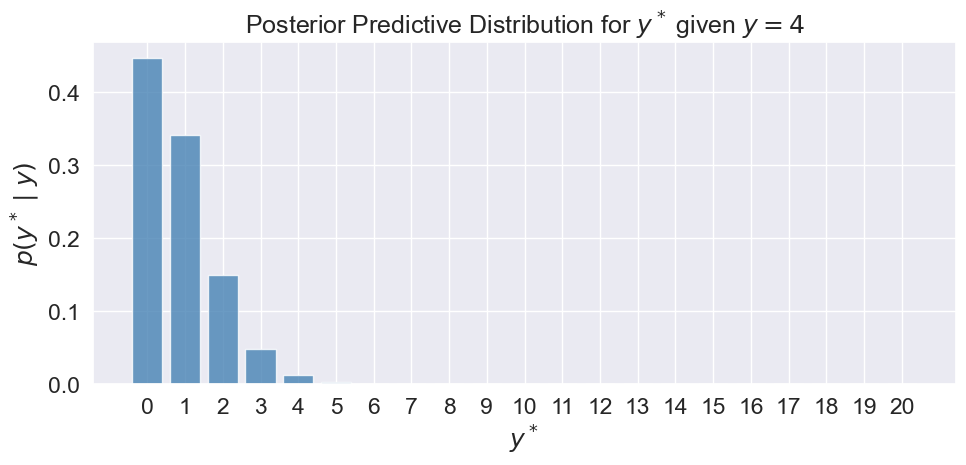

In [15]:
def beta_binomial_pmf(y_star, N_star, a, b):
    return comb(N_star, y_star) * beta_fun(a + y_star, b + N_star - y_star) / beta_fun(a, b)

y_star_vals = np.arange(0, N_star + 1)
ppd = np.array([beta_binomial_pmf(int(ys), N_star, a_N, b_N) for ys in y_star_vals])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(y_star_vals, ppd, color='steelblue', alpha=0.8)
ax.set_xlabel('$y^*$')
ax.set_ylabel('$p(y^* \\mid y)$')
ax.set_title('Posterior Predictive Distribution for $y^*$ given $y = 4$')
ax.set_xticks(y_star_vals)
plt.tight_layout()
plt.show()

### Task 1.4: What is the posterior predictive probability that at least one of the next $N^* = 20$ customers will make a purchase?

Using the complement rule:
$$P(y^* \geq 1 \mid y) = 1 - P(y^* = 0 \mid y)$$

Applying the Beta-Binomial PMF with $y^* = 0$:
$$P(y^* = 0 \mid y) = \binom{N^*}{0} \frac{B(a_N,\; b_N + N^*)}{B(a_N,\; b_N)} = \frac{B(5,\; 132)}{B(5,\; 112)}$$

In [16]:
p_zero = beta_binomial_pmf(0, N_star, a_N, b_N)
p_at_least_one = 1 - p_zero
print(f"P(y* = 0  | y) = {p_zero:.6f}")
print(f"P(y* >= 1 | y) = {p_at_least_one:.6f}")

P(y* = 0  | y) = 0.445609
P(y* >= 1 | y) = 0.554391


### Task 1.5: Compute mean and variance of the posterior predictive distribution for $y^*$.

Using the Beta-Binomial PMF computed in Task 1.3, the mean and variance are computed analytically as:
$$\mathbb{E}_{p(y^*|y)}[y^*] = \sum_{k=0}^{N^*} k \cdot p(y^* = k \mid y)$$

$$\text{Var}_{p(y^*|y)}[y^*] = \sum_{k=0}^{N^*} k^2 \cdot p(y^* = k \mid y) - \left(\mathbb{E}[y^*]\right)^2$$

In [17]:
# Mean and variance using the PPD PMF from Task 1.3
ppd_mean = np.sum(y_star_vals * ppd)
ppd_var  = np.sum(y_star_vals**2 * ppd) - ppd_mean**2

print(f"Posterior predictive mean:     {ppd_mean:.4f}")
print(f"Posterior predictive variance: {ppd_var:.4f}")

Posterior predictive mean:     0.8547
Posterior predictive variance: 0.9499


## Part 2: Linear Gaussian Systems

Let $\mathbf{z}_1, \mathbf{z}_2 \in \mathbb{R}^2$ and $y \in \mathbb{R}$ be random variables and consider the following linear Gaussian system:

$$\mathbf{z}_1 \sim \mathcal{N}(\mathbf{0},\, v\mathbf{I}) \tag{3}$$

$$\mathbf{z}_2 \mid \mathbf{z}_1 \sim \mathcal{N}(\mathbf{z}_1,\, v\mathbf{I}) \tag{4}$$

$$y \mid \mathbf{z}_2 \sim \mathcal{N}(\mathbf{a}^T\mathbf{z}_2,\, \sigma^2) \tag{5}$$

where $\mathbf{a} \in \mathbb{R}^2$ is a constant vector. The joint distribution of $(\mathbf{z}_1, \mathbf{z}_2, y)$ is:

$$p(y, \mathbf{z}_1, \mathbf{z}_2) = p(y \mid \mathbf{z}_2)\, p(\mathbf{z}_2 \mid \mathbf{z}_1)\, p(\mathbf{z}_1) \tag{6}$$

### Task 2.1: Determine the distribution $p(y)$.

**Step 1: Compute $p(\mathbf{z}_2)$.**

The pair $(p(\mathbf{z}_1),\, p(\mathbf{z}_2|\mathbf{z}_1))$ forms a linear Gaussian system matching Murphy eqs. (3.33)–(3.34) with
$\mathbf{W} = \mathbf{I}$, $\mathbf{b} = \mathbf{0}$, $\boldsymbol{\mu}_z = \mathbf{0}$, $\Sigma_z = v\mathbf{I}$, $\Sigma_y = v\mathbf{I}$.
Applying eq. (3.38):

$$p(\mathbf{z}_2) = \mathcal{N}\!\left(\mathbf{z}_2 \mid \mathbf{W}\boldsymbol{\mu}_z + \mathbf{b},\; \Sigma_y + \mathbf{W}\Sigma_z\mathbf{W}^T\right)
= \mathcal{N}\!\left(\mathbf{z}_2 \mid \mathbf{0},\; v\mathbf{I} + v\mathbf{I}\right)
= \mathcal{N}\!\left(\mathbf{z}_2 \mid \mathbf{0},\; 2v\mathbf{I}\right)$$

**Step 2: Compute $p(y)$.**

Now treat $p(\mathbf{z}_2) = \mathcal{N}(\mathbf{0}, 2v\mathbf{I})$ as the prior and $p(y|\mathbf{z}_2) = \mathcal{N}(\mathbf{a}^T\mathbf{z}_2, \sigma^2)$ as the likelihood, with
$\mathbf{W} = \mathbf{a}^T$, $\mathbf{b} = 0$, $\Sigma_z = 2v\mathbf{I}$, $\Sigma_y = \sigma^2$.
Applying eq. (3.38) again:

$$p(y) = \mathcal{N}\!\left(y \mid \mathbf{a}^T\mathbf{0},\; \sigma^2 + \mathbf{a}^T(2v\mathbf{I})\mathbf{a}\right)$$

$$\boxed{p(y) = \mathcal{N}\!\left(y \mid 0,\; \sigma^2 + 2v\|\mathbf{a}\|^2\right)}$$

### Task 2.2: Determine the distribution $p(y, \mathbf{z}_2 \mid \mathbf{z}_1)$.

Conditioned on $\mathbf{z}_1$, treat $\mathbf{z}_2 \mid \mathbf{z}_1 \sim \mathcal{N}(\mathbf{z}_1, v\mathbf{I})$ as the prior and $y \mid \mathbf{z}_2 \sim \mathcal{N}(\mathbf{a}^T\mathbf{z}_2, \sigma^2)$ as the likelihood. This matches Murphy eqs. (3.33)–(3.34) with $\boldsymbol{\mu}_z = \mathbf{z}_1$, $\Sigma_z = v\mathbf{I}$, $\mathbf{W} = \mathbf{a}^T$, $\mathbf{b} = 0$, $\Sigma_y = \sigma^2$. Applying the joint distribution formula eqs. (3.35)–(3.36):

$$p(y, \mathbf{z}_2 \mid \mathbf{z}_1) = \mathcal{N}\!\left(\begin{pmatrix}\mathbf{z}_2 \\ y\end{pmatrix} \Bigg| \begin{pmatrix}\mathbf{z}_1 \\ \mathbf{a}^T\mathbf{z}_1\end{pmatrix},\; \begin{pmatrix} v\mathbf{I} & v\mathbf{a} \\ v\mathbf{a}^T & \sigma^2 + v\mathbf{a}^T\mathbf{a} \end{pmatrix}\right)$$

where the joint covariance blocks follow from eq. (3.36): $\Sigma_z \mathbf{W}^T = v\mathbf{I}\cdot\mathbf{a} = v\mathbf{a}$ and $\Sigma_y + \mathbf{W}\Sigma_z\mathbf{W}^T = \sigma^2 + v\|\mathbf{a}\|^2$.

### Task 2.3: Determine the distribution $p(y \mid \mathbf{z}_1)$.

$p(y \mid \mathbf{z}_1)$ is the marginal of $y$ from the joint $p(y, \mathbf{z}_2 \mid \mathbf{z}_1)$ derived in Task 2.2, which corresponds to the lower-right block of that joint distribution. Equivalently, applying eq. (3.38) directly with $\mathbf{z}_2 \mid \mathbf{z}_1 \sim \mathcal{N}(\mathbf{z}_1, v\mathbf{I})$ as the prior:

$$p(y \mid \mathbf{z}_1) = \mathcal{N}\!\left(y \mid \mathbf{a}^T\mathbf{z}_1,\; \sigma^2 + \mathbf{a}^T v\mathbf{I}\, \mathbf{a}\right)$$

$$\boxed{p(y \mid \mathbf{z}_1) = \mathcal{N}\!\left(y \mid \mathbf{a}^T\mathbf{z}_1,\; \sigma^2 + v\|\mathbf{a}\|^2\right)}$$

### Task 2.4: Determine the distribution $p(\mathbf{z}_1 \mid y)$.

By Bayes' rule:
$$p(\mathbf{z}_1 \mid y) \propto p(y \mid \mathbf{z}_1)\, p(\mathbf{z}_1)$$

From Task 2.3, the likelihood is $p(y \mid \mathbf{z}_1) = \mathcal{N}(y \mid \mathbf{a}^T\mathbf{z}_1,\; \sigma^2 + v\|\mathbf{a}\|^2)$, and the prior is $p(\mathbf{z}_1) = \mathcal{N}(\mathbf{z}_1 \mid \mathbf{0},\, v\mathbf{I})$. This is a linear Gaussian system with $\mathbf{W} = \mathbf{a}^T$, $\mathbf{b} = 0$, $\boldsymbol{\mu}_z = \mathbf{0}$, $\Sigma_z = v\mathbf{I}$, $\Sigma_y = \sigma^2 + v\|\mathbf{a}\|^2$. Applying Murphy eq. (3.37) (Bayes rule for Gaussians):

$$\Sigma_{\mathbf{z}_1|y}^{-1} = \Sigma_z^{-1} + \mathbf{W}^T \Sigma_y^{-1} \mathbf{W} = \frac{1}{v}\mathbf{I} + \frac{\mathbf{a}\mathbf{a}^T}{\sigma^2 + v\|\mathbf{a}\|^2}$$

$$\boldsymbol{\mu}_{\mathbf{z}_1|y} = \Sigma_{\mathbf{z}_1|y}\left[\mathbf{W}^T \Sigma_y^{-1}(y - \mathbf{b}) + \Sigma_z^{-1}\boldsymbol{\mu}_z\right] = \frac{y}{\sigma^2 + v\|\mathbf{a}\|^2}\, \Sigma_{\mathbf{z}_1|y}\, \mathbf{a}$$

Therefore:

$$\boxed{p(\mathbf{z}_1 \mid y) = \mathcal{N}\!\left(\mathbf{z}_1 \,\Big|\, \frac{y}{\sigma^2 + v\|\mathbf{a}\|^2}\, \Sigma_{\mathbf{z}_1|y}\, \mathbf{a},\; \Sigma_{\mathbf{z}_1|y}\right)}$$

where $\;\Sigma_{\mathbf{z}_1|y}^{-1} = \dfrac{1}{v}\mathbf{I} + \dfrac{\mathbf{a}\mathbf{a}^T}{\sigma^2 + v\|\mathbf{a}\|^2}$.

## Part 3: A Conjugate Model for Count Data

Consider the Poisson-Gamma model where the likelihood is Poisson and the prior on the rate $\lambda > 0$ is a Gamma distribution:

$$p(y_i|\lambda) = \frac{\lambda^{y_i} e^{-\lambda}}{y_i!}, \quad y_i \in \{0, 1, 2, \ldots\} \tag{7}$$

$$p(\lambda|a_0, b_0) = \frac{b_0^{a_0}}{\Gamma(a_0)}\, \lambda^{a_0-1} e^{-b_0\lambda} \tag{8}$$

where $\Gamma(x)$ is the gamma function, and $a_0 > 0$, $b_0 > 0$ are the shape and rate hyperparameters. The full model is:

$$y_i \mid \lambda \sim \text{Poisson}(\lambda) \tag{9}$$

$$\lambda \sim \text{Gamma}(a_0, b_0) \tag{10}$$

where $\{y_i\}$ are conditionally independent given $\lambda$, and we observe $\mathbf{y} = \{y_i\}_{i=1}^N$.

### Task 3.1: Determine the joint distribution $p(\mathbf{y}, \lambda)$.

Using conditional independence of $\{y_i\}$ given $\lambda$:

$$p(\mathbf{y}, \lambda) = p(\lambda)\prod_{i=1}^{N} p(y_i|\lambda)
= \frac{b_0^{a_0}}{\Gamma(a_0)}\lambda^{a_0-1}e^{-b_0\lambda} \cdot \prod_{i=1}^{N}\frac{\lambda^{y_i}e^{-\lambda}}{y_i!}$$

Collecting powers of $\lambda$ and exponential terms:

$$\boxed{p(\mathbf{y}, \lambda) = \frac{b_0^{a_0}}{\Gamma(a_0)\prod_{i=1}^{N} y_i!}\cdot \lambda^{\,a_0 - 1 + \sum_{i=1}^{N} y_i}\cdot e^{-(b_0 + N)\lambda}}$$

### Task 3.2: Show that the functional form of a Gamma distribution is $\log p(\lambda|a,b) = (a-1)\log\lambda - b\lambda + \text{constant}$.

Taking the logarithm of eq. (8):

$$\log p(\lambda|a, b) = a\log b - \log\Gamma(a) + (a-1)\log\lambda - b\lambda$$

Since $a\log b - \log\Gamma(a)$ does not depend on $\lambda$, we have:

$$\log p(\lambda|a, b) = (a-1)\log\lambda - b\lambda + \underbrace{a\log b - \log\Gamma(a)}_{\text{constant w.r.t. }\lambda}$$

### Task 3.3: Derive the posterior $p(\lambda|\mathbf{y})$ and show it is a Gamma distribution.

By Bayes' rule, $p(\lambda|\mathbf{y}) \propto p(\mathbf{y}, \lambda)$. Taking the log of the joint from Task 3.1:

$$\log p(\lambda|\mathbf{y}) = \log p(\mathbf{y}, \lambda) + \text{const} = \left(a_0 - 1 + \sum_{i=1}^{N} y_i\right)\log\lambda - (b_0 + N)\lambda + \text{const}$$

Matching with the functional form from Task 3.2, $(a_N - 1)\log\lambda - b_N\lambda$, we identify:

$$a_N = a_0 + \sum_{i=1}^{N} y_i, \qquad b_N = b_0 + N$$

This is exactly the log-density of a $\text{Gamma}(a_N, b_N)$ distribution, so:

$$\boxed{p(\lambda|\mathbf{y}) = \text{Gamma}\!\left(a_0 + \textstyle\sum_{i=1}^{N} y_i,\; b_0 + N\right)}$$

### Task 3.4: Determine the posterior for $\lambda$ given the data and report the mean.

Data: $y_1=7,\; y_2=4,\; y_3=8,\; y_4=11,\; y_5=12$, so $N=5$ and $\sum y_i = 42$.
Hyperparameters: $a_0 = 1$, $b_0 = \tfrac{1}{10}$.

Substituting into the conjugate update from Task 3.3:
$$a_N = 1 + 42 = 43, \qquad b_N = \tfrac{1}{10} + 5 = 5.1$$

The posterior mean of a $\text{Gamma}(a, b)$ distribution is $\mathbb{E}[\lambda] = a/b$, so:
$$\mathbb{E}[\lambda|\mathbf{y}] = \frac{a_N}{b_N} = \frac{43}{5.1}$$

In [18]:
# Data and hyperparameters
y_data = np.array([7, 4, 8, 11, 12])
N3 = len(y_data)
a0_3, b0_3 = 1, 0.1

# Conjugate posterior update
a_N3 = a0_3 + np.sum(y_data)
b_N3 = b0_3 + N3
print(f"Posterior: Gamma(a_N={a_N3}, b_N={b_N3})")

# Posterior mean
posterior_mean_lam = a_N3 / b_N3
print(f"Posterior mean E[lambda | y] = {a_N3}/{b_N3} = {posterior_mean_lam:.4f}")

Posterior: Gamma(a_N=43, b_N=5.1)
Posterior mean E[lambda | y] = 43/5.1 = 8.4314


### Task 3.5: Plot $p(\lambda)$ and $p(\lambda|\mathbf{y})$ for $\lambda \in [0, 30]$.

We implement the log-density for numeric stability and exponentiate:

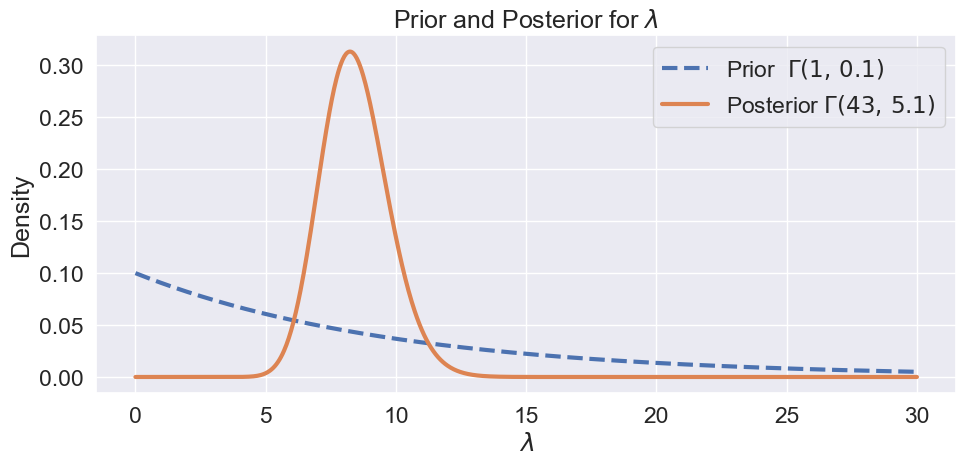

In [10]:
from scipy.special import gammaln

def log_gamma_pdf(lam, a, b):
    """Log-density of Gamma(a, b) evaluated at lam (rate parameterisation)."""
    return a * np.log(b) - gammaln(a) + (a - 1) * np.log(lam) - b * lam

lam_vals = np.linspace(1e-6, 30, 1000)

log_prior = log_gamma_pdf(lam_vals, a0_3, b0_3)
log_post  = log_gamma_pdf(lam_vals, a_N3,  b_N3)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lam_vals, np.exp(log_prior), label=f'Prior  $\\Gamma({a0_3},\, {b0_3})$', linestyle='--')
ax.plot(lam_vals, np.exp(log_post),  label=f'Posterior $\\Gamma({a_N3},\, {b_N3})$')
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('Density')
ax.set_title('Prior and Posterior for $\\lambda$')
ax.legend()
plt.tight_layout()
plt.show()